In [3]:
import sys
import os
sys.path.append(os.path.abspath('..')) #for accesing folder

In [3]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#print(f"PyTorch version: {torch.__version__}")

In [18]:
#loading Train.csv dataset
train_df = pd.read_csv('../dataset/Train.csv', engine='python', encoding='utf-8')#python engine for not getting error - long message about C engine
train_df.reset_index(drop=True) #resetting index to start from 0
train_df.head(5)

,Query,Label
0,The film 'Nightbreed' is one of the best horro...,0.0
1,The story for Hare Rama Hare Krishna actually ...,0.0
2,"1"" where 6347 = 6347 union all select null,nul...",1.0
3,jk dv1z0r39am1wjiiumia9xrxdowuo87f 110dcc d0ej...,1.0
4,1'|| ( select 'fdkl' where 4572 = 4572 uni...,1.0


In [24]:
train_df.shape #(98085, 2) - 98085 rows and 2 columns (query and label)
train_df.columns.to_list() #['Query', 'Label'] - columns names
train_df['Label'].value_counts()
#0 (non-SQLi) - 51377
#1 (SQLi) - 46685

Label
0.0    51377
1.0    46685
Name: count, dtype: int64

In [44]:
train_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access
#train_df.columns.to_list()

#removing NaN values
train_df = train_df.dropna()
#label setting as int values

train_df['label'] = train_df['label'].astype(int)
train_df.head(5)

train_df[train_df['label'] == 1].head(3) #first 3 SQLi queries

,query,label
2,"1"" where 6347 = 6347 union all select null,nul...",1
3,jk dv1z0r39am1wjiiumia9xrxdowuo87f 110dcc d0ej...,1
4,1'|| ( select 'fdkl' where 4572 = 4572 uni...,1


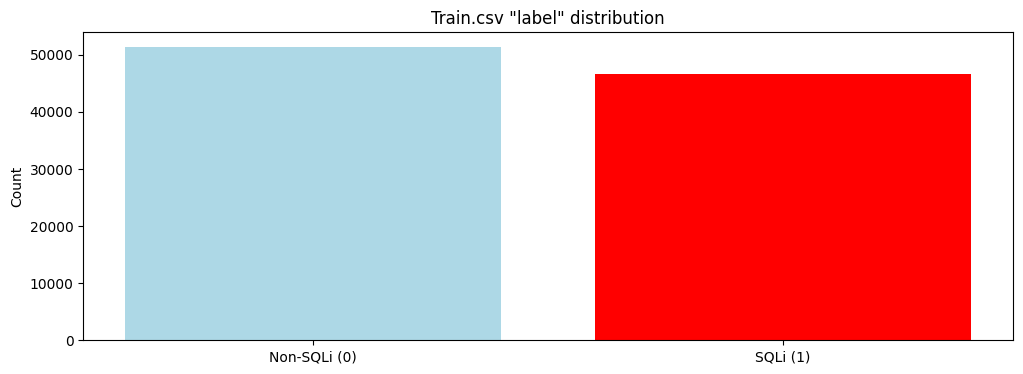

In [72]:
# visualization of class distribution (SQLi vs non-SQLi) in the training dataset
plt.figure(figsize=(12, 4))

train_counts = train_df['label'].value_counts()
plt.bar(['Non-SQLi (0)', 'SQLi (1)'], train_counts.values, color=['lightblue', 'red'])
plt.title('Train.csv "label" distribution')
plt.ylabel('Count')


plt.savefig('../results/traininglabel_distribution.png', dpi=300, bbox_inches='tight')
plt.show()